## Неделя 0. Домашка по Python

In [1]:
import numpy as np 
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time
import matplotlib.pyplot as plt
import seaborn as sns

import os
from dotenv import load_dotenv

In [2]:
df = pd.read_excel("Reestr1.xlsx", nrows=5500, header = 2)

In [3]:
need_columns = ["№ п/п", 'Наименование / ФИО', 'Тип субъекта', "Категория", "ИНН", "Основной вид деятельности"]

In [4]:
df = df[need_columns]

df_filter = df[(df["Тип субъекта"] == "Юридическое лицо") & ((df["Категория"] == "Малое предприятие") | (df["Категория"] == "Среднее предприятие")) & (df["Основной вид деятельности"].str.contains("41.2", na=False)) ]

In [5]:
inn = df_filter["ИНН"].to_numpy()

Фкнкция для сбора адресов

In [6]:
def build_address(item):
    parts = [
        item.get("region"),
        item.get("district"),
        item.get("city"),
        item.get("settlement"),
        item.get("street"),
        item.get("house"),
        item.get("building"),
        item.get("office"),
    ]

    address = ", ".join(str(p) for p in parts if p)
    return address

Сбор кодов с сайта БФО для просмотра бухгалтерской отчетности

In [7]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36",
    "Accept": "*/*",
    "Accept-Language": "ru,en;q=0.9",
}

code_company = []
addresses = {}

for i in inn:   
    session = requests.Session()

    try:
        res = session.get(f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={i}", headers=headers, timeout=20).json()

    except:
        continue

    time.sleep(1)
    if res["content"]:
        code_company.append(res["content"][0]["id"])

        full_address = build_address(res["content"][0])
        addresses[int(i)] = full_address

Сбор данных финансовой ответности для последующей обработки.

Коды:

- 2300 - Прибыль/убыток до налогообложения
- 2330 - Проценты к уплате

**EBIT** = 2300 + 2330

- 2400 - Чистая прибыль
- 2110 - Выручка

In [8]:

ebit_data = {} # Словарь для подсчета EBIT

net_profit = {} # Словарь для графиков расчета чистой прибыли

revenue = {} # Словарь для выручки для топ-100


for i, code in zip(inn, code_company):
        ebit_data[int(i)] = {}
        net_profit[int(i)] = {}
        revenue[int(i)] = {}

        try: 
                bfo_data = requests.get(f"https://bo.nalog.gov.ru/nbo/organizations/{code}/bfo/", headers=headers, timeout=20).json()

        except Exception as e:
                print(f"Ошибка запроса для ИНН {inn}: {e}")
                continue

        for period in bfo_data:

                year = int(period["period"])

                financial = period["typeCorrections"][0]["correction"]["financialResult"]

                profit_before_tax = financial.get("current2300", 0)
                interest_expense = financial.get("current2330", 0)

                final_ebit = profit_before_tax + interest_expense 
                ebit_data[i][year]= final_ebit

                company_net_profit = financial.get("current2400", 0)
                net_profit[i][year] = int(company_net_profit)

                company_revenue = financial.get("current2110", 0)
                revenue[i][year] = company_revenue

## Задание 1

Определите насколько перспективна отрасль строительства с помощью подсчёта EBIT всех компаний по годам. 

In [9]:
df_ebit = pd.DataFrame.from_dict(ebit_data, orient = "index").reset_index()
df_ebit = df_ebit.rename(columns={"index": "ИНН"})

In [10]:
df_ebit["Прирост с 2021 по 2025"] = (df_ebit[2025] - df_ebit[2021])
df_ebit["Средний прирост за все года"] = df_ebit[[2021, 2022, 2023, 2024, 2025]].mean(axis=1)

df_ebit = df_ebit[["ИНН", 2021, 2022, 2023, 2024, 2025, "Средний прирост за все года","Прирост с 2021 по 2025"]]

df_ebit = df_ebit.dropna(subset= ["Средний прирост за все года", "Прирост с 2021 по 2025"])

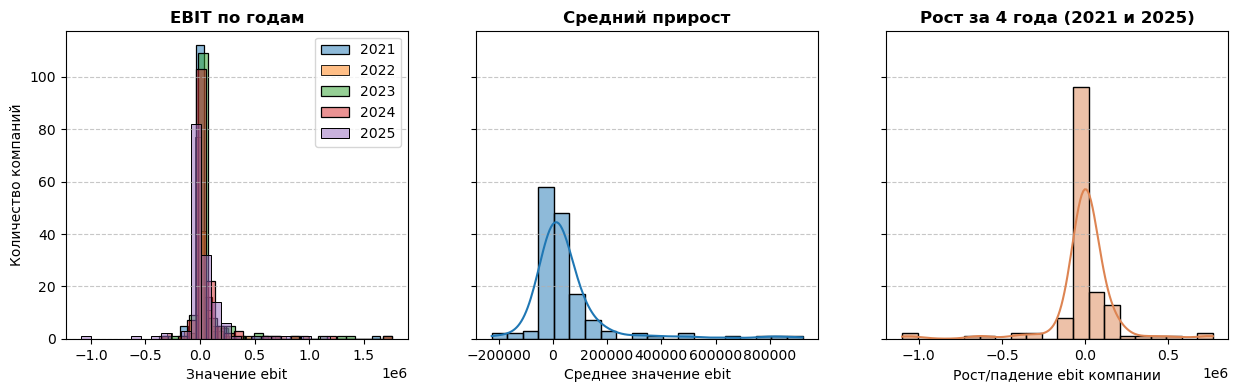

In [11]:
fig, ax = plt.subplots(1, 3, figsize = (15, 4), sharey = True)

sns.histplot(df_ebit, x = 2021, ax = ax[0], alpha = 0.5, label = 2021)
sns.histplot(df_ebit, x = 2022, ax = ax[0], alpha = 0.5, label = 2022)
sns.histplot(df_ebit, x = 2023, ax = ax[0], alpha = 0.5, label = 2023)
sns.histplot(df_ebit, x = 2024, ax = ax[0], alpha = 0.5, label = 2024)
sns.histplot(df_ebit, x = 2025, ax = ax[0], alpha = 0.5, label = 2025)
ax[0].set_title("EBIT по годам", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Значение ebit")
ax[0].set_ylabel("Количество компаний")
ax[0].legend()
ax[0].grid(True, axis="y", alpha=0.7, linestyle="--")

sns.histplot(df_ebit, x = "Средний прирост за все года", bins = 20, kde = True, ax = ax[1])
ax[1].set_title("Средний прирост", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Среднее значение ebit")
ax[1].set_ylabel("Количество компаний")
ax[1].grid(True, axis="y", alpha=0.7, linestyle="--")

sns.histplot(df_ebit, x = "Прирост с 2021 по 2025", bins = 20, kde = True, ax = ax[2], color = "#DD8452")
ax[2].set_title("Рост за 4 года (2021 и 2025)", fontsize=12, fontweight="bold")
ax[2].set_xlabel("Рост/падение ebit компании")
ax[2].set_ylabel("Количество компаний")
ax[2].grid(True, axis="y", alpha=0.7, linestyle="--")

### Наблюдения по графикам:

- Основная масса компаний сосредоточена в 0 по значению EBIT. Это явный пик, который приходится на диапазон от 0 до 50 000 компаний.
- Только небольшая доля компаний имеет отрицательный показатель EBIT.
- График со средним приростом правосторонне скошен, редкие крупные компании (приростом до 500 000) растягивают правый хвост.
- Правый график более симметричен, но чётко видны выбросы с обеих сторон (от -600 000 до +600 000).

### Вывод о перспективности отрасли:

- Отрасль строительства не убыточна, но и не демонстрирует роста. Видна скорее стагнация.
- Отрасль стабильна относительно нуля.
- Есть крупные выбросы, как в строрну роста, так и в сторону падения показателя EBIT.

## Задание 2

Построить графики (x=процент роста чистой прибыли компании относительно N-летней давности, y=Количество компаний с таким процентном) 

*x-целое число

In [12]:
df_net_profit = pd.DataFrame.from_dict(net_profit, orient = "index").reset_index()
df_net_profit  = df_net_profit.rename(columns={"index": "Чистая прибыль"})
df_net_profit = df_net_profit.dropna(subset=[2021, 2022, 2023, 2024, 2025])

for i in range(2021,2026):
    df_net_profit[i] = df_net_profit[i].astype(int)

In [13]:
df_net_profit["Процент роста 1 год назад"] = ((df_net_profit[2025] - df_net_profit[2024])/df_net_profit[2024])
df_net_profit["Процент роста 2 год назад"] = ((df_net_profit[2025] - df_net_profit[2023])/df_net_profit[2023])
df_net_profit["Процент роста 3 год назад"] = ((df_net_profit[2025] - df_net_profit[2022])/df_net_profit[2022])

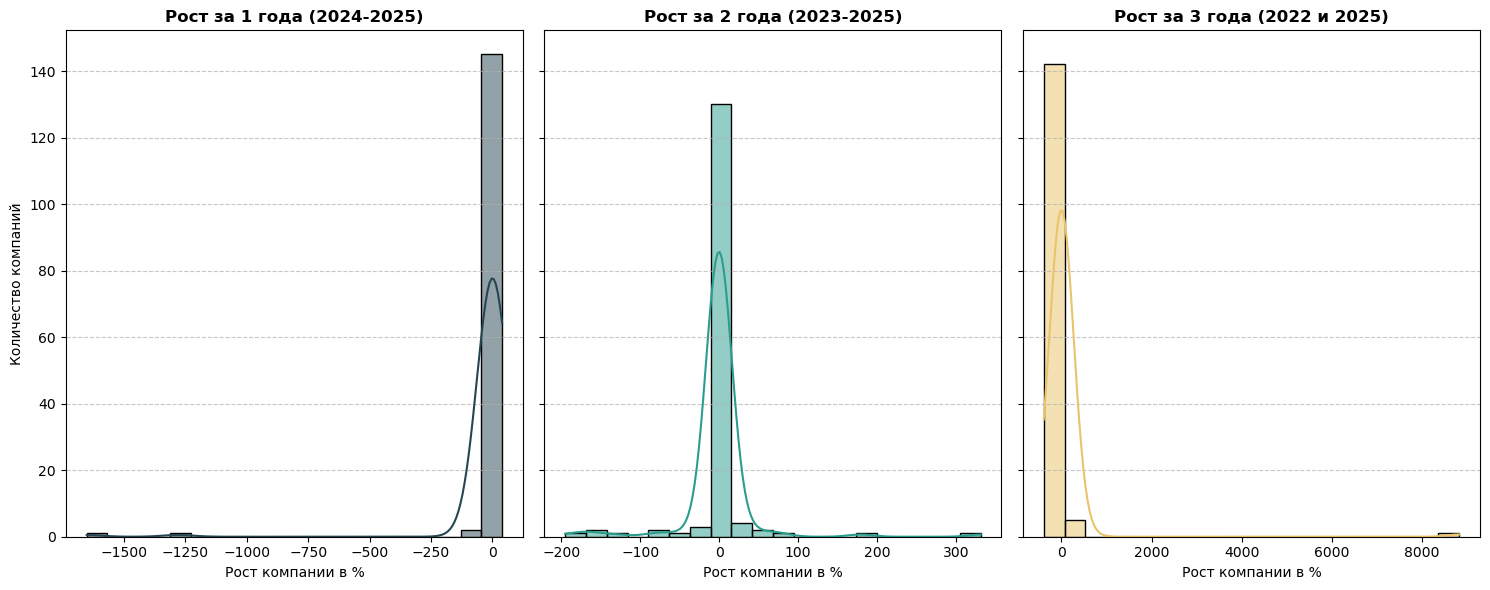

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

colors = ["#264653", "#2A9D8F", "#E9C46A"]

sns.histplot(df_net_profit, x = "Процент роста 1 год назад", ax = ax[0], bins = 20, kde= True, color = colors[0])
ax[0].set_title("Рост за 1 года (2024-2025)", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Рост компании в %")
ax[0].set_ylabel("Количество компаний")
ax[0].grid(True, axis = "y", alpha=0.7, linestyle = "--")

sns.histplot(df_net_profit, x = "Процент роста 2 год назад", ax = ax[1], bins = 20, kde= True, color = colors[1])
ax[1].set_title("Рост за 2 года (2023-2025)", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Рост компании в %")
ax[1].set_ylabel("Количество компаний")
ax[1].grid(True, axis = "y", alpha=0.7, linestyle = "--")

sns.histplot(df_net_profit, x = "Процент роста 3 год назад", ax = ax[2], bins = 20, kde= True, color = colors[2])
ax[2].set_title("Рост за 3 года (2022 и 2025)", fontsize=12, fontweight="bold")
ax[2].set_xlabel("Рост компании в %")
ax[2].set_ylabel("Количество компаний")
ax[2].grid(True, axis = "y", alpha=0.7, linestyle = "--")

plt.tight_layout()

### Выводы по графикам:

Общая закономерность - концентрация вокргу нуля. Пик в каждом графика находится у 0.

- График роста за 1 год (2024-2025) левостороне скошен. Видно концентрацию вокруг нуля и несколько больших выбросов в отрицательные значения роста.
- По оси Х у графика роста за 2 год (с 2023 по 2025) можно видеть разброс в обе стороны, как в положительную, так и отрицательную. Мало выбросов.
- График за 3 года роста (с 2022 по 2025) правосторонне скошен. Имеется выброс более 8000% по показателю роста компании.

#### Общий вывод

- Компании в выборке демонстрируют стабильную стагнацию в 0%.
- С увеличением количества лет для анализа растёт дисперсия и ассиметрия.

## Задание 3

Нанесите топ 100 компаний по выручке на карту по месту регистрации.

In [15]:
df_revenue = pd.DataFrame.from_dict(revenue, orient="index").reset_index()
df_revenue = df_revenue.rename(columns={"index": "ИНН"})

df_addresses = pd.DataFrame.from_dict(addresses, orient = "index").reset_index()
df_addresses = df_addresses.rename(columns={"index": "ИНН", 0: "Адрес"})

df_3_excer = pd.merge(df_addresses, df_revenue, on = "ИНН", how = "inner")

In [16]:
df_3_excer["Сумма выручки"] = df_3_excer[[2021, 2022, 2023, 2024, 2025]].sum(axis=1)

In [17]:
df_3 = df_3_excer.sort_values(by = "Сумма выручки", ascending=False)

df_3 = df_3[:100].reset_index(drop=True)

In [18]:
def geocode_nominatim(address: str):
    url = "https://nominatim.openstreetmap.org/search"
    params = {
        "q": address,
        "format": "json",
        "limit": 1,
        "countrycodes": "ru"
    }
    headers = {
        "User-Agent": "construction-industry-research/1.0 (student project)"
    }

    resp = requests.get(url, params=params, headers=headers, timeout=15)
    resp.raise_for_status()
    data = resp.json()

    if data:
        return float(data[0]["lat"]), float(data[0]["lon"])
    return None, None

In [19]:
latitudes = []
longitudes = []

for i, address in enumerate(df_3["Адрес"]):
    try:
        lat, lon = geocode_nominatim(address)
    except Exception as e:
        print(f"Ошибка геокодирования для '{address}': {e}")
        lat, lon = None, None

    latitudes.append(lat)
    longitudes.append(lon)
    
    if (i + 1) % 10 == 0:
        print(f"Обработано {i+1}/{len(df_3)}")
    
    time.sleep(1)

df_3["lat"] = latitudes
df_3["lon"] = longitudes

Обработано 10/100
Обработано 20/100
Обработано 30/100
Обработано 40/100
Обработано 50/100
Обработано 60/100
Обработано 70/100
Обработано 80/100
Обработано 90/100
Обработано 100/100


In [23]:
import plotly.express as px

df_map = df_3.dropna(subset=["lat", "lon"]).reset_index(drop=True)

fig = px.scatter_mapbox(
    df_map,
    lat="lat",
    lon="lon",
    size="Сумма выручки",
    color="Сумма выручки",
    hover_name="Адрес",
    hover_data={"Сумма выручки": ":,.0f", "lat": False, "lon": False},
    color_continuous_scale="Viridis",
    size_max=30,
    zoom=3,
    center={"lat": 60, "lon": 45},
    height=700,
    title="Топ-50 строительных компаний по выручке (2021–2025) — карта регистрации"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin={"r": 0, "t": 50, "l": 0, "b": 0}
)

fig.show()

C:\Users\s7omb\AppData\Local\Temp\ipykernel_8488\406545374.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

